In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import wine_common as wine
import importlib
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:

def plot_data(X, y):
    # X: array o dataframe one-hot (n_samples, n_features)
    # y: labels 0/1

    X_np = X.values if hasattr(X, "values") else np.asarray(X)
    y_np = y.values.ravel() if hasattr(y, "values") else np.asarray(y).ravel()

    # =====================
    # PCA 2D
    # =====================
    pca = PCA(n_components=2, random_state=42)
    Z_pca = pca.fit_transform(X_np)

    plt.figure()
    plt.scatter(Z_pca[y_np == 0, 0], Z_pca[y_np == 0, 1], c="red", label="Class 0", s=20, alpha=1)
    plt.scatter(Z_pca[y_np == 1, 0], Z_pca[y_np == 1, 1], c="green", label="Class 1", s=20, alpha=0.1)

    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.title("MONK – PCA 2D")
    plt.legend()
    plt.grid(True)
    plt.show()

    # =====================
    # t-SNE 2D
    # =====================
    tsne = TSNE(
        n_components=2,
        random_state=42,
        init="pca",
        learning_rate="auto",
        perplexity=30
    )
    Z_tsne = tsne.fit_transform(X_np)

    plt.figure()
    plt.scatter(Z_tsne[y_np==0,0], Z_tsne[y_np==0,1], c="red",   marker="o", s=40, alpha=1.0, label="Class 0")
    plt.scatter(Z_tsne[y_np==1,0], Z_tsne[y_np==1,1], c="green", marker="o", s=30, alpha=0.1, label="Class 1")

    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.title("MONK – t-SNE 2D")
    plt.legend()
    plt.grid(True)
    plt.show()



<hr/>

<h4>Data Loading</h4>

In [34]:
importlib.reload(wine)
df_train, df_test = wine.stratified_split()
X_tr, y_tr, X_ts, y_ts = wine.split_and_prepare_dataset(df_train, df_test)
features_names = df_train.drop(columns=['quality', 'type']).columns
wine.dataset_introspection(df_train, df_test)

,Property,Training,Test
0,Number of samples,5199,1298
1,Number of features,11,11
2,Class values,"[3, 4, 5, 6, 7, 8, 9]","[3, 4, 5, 6, 7, 8]"
3,Class balance,"quality 3 = 24, quality 4 = 182, quality 5 = 1...","quality 3 = 6, quality 4 = 34, quality 5 = 421..."


In [35]:
X_tr.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type
0,0.214876,0.060000,0.192771,0.027607,0.064784,0.274914,0.631922,0.128976,0.604651,0.157303,0.246377,0.0
1,0.272727,0.120000,0.204819,0.211656,0.096346,0.233677,0.596091,0.221515,0.271318,0.174157,0.159420,0.0
2,0.231405,0.220000,0.144578,0.065951,0.247508,0.316151,0.449511,0.146520,0.348837,0.151685,0.202899,0.0
3,0.165289,0.146667,0.072289,0.015337,0.044850,0.384880,0.511401,0.101793,0.511628,0.207865,0.362319,0.0
4,0.520661,0.246667,0.138554,0.019939,0.121262,0.061856,0.039088,0.204935,0.387597,0.241573,0.188406,1.0


In [36]:
X_ts.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type
0,0.431034,0.193237,0.454545,0.045662,0.129902,0.020833,0.011547,0.396736,0.371901,0.270270,0.716667,1.0
1,0.215517,0.067633,0.404040,0.036530,0.068627,0.076389,0.184758,0.156937,0.256198,0.189189,0.700000,0.0
2,0.250000,0.570048,0.020202,0.050228,0.088235,0.013889,0.009238,0.563716,0.561983,0.243243,0.250000,1.0
3,0.181034,0.193237,0.494949,0.278539,0.083333,0.208333,0.496536,0.507219,0.322314,0.198198,0.216667,0.0
4,0.232759,0.125604,0.393939,0.073059,0.066176,0.104167,0.219400,0.313245,0.347107,0.297297,0.483333,0.0


<hr/>

<h4>Data Analysis</h4>

<h5>Data Distribution</h5>
<p>The analysis starts from the distribution of the target variable (wine quality), which shows a strong imbalance toward intermediate quality levels. This characteristic has important implications for feature relevance interpretation and model evaluation.</p>

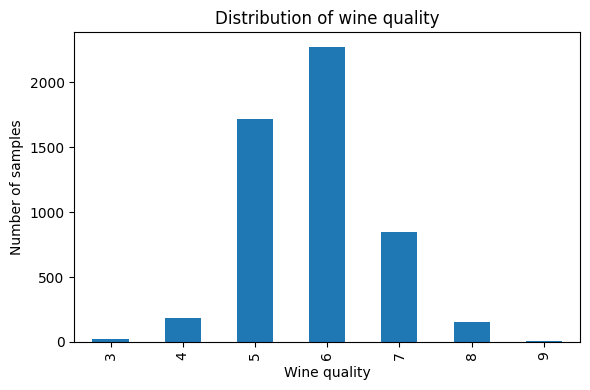

In [37]:
plt.figure(figsize=(6,4))
df_train['quality'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Wine quality')
plt.ylabel('Number of samples')
plt.title('Distribution of wine quality')
plt.tight_layout()
plt.show()

<h5>Data Comparison</h5>
<p>Compare target with feature by means of boxplot.</p>
$$p(x_j | y) $$

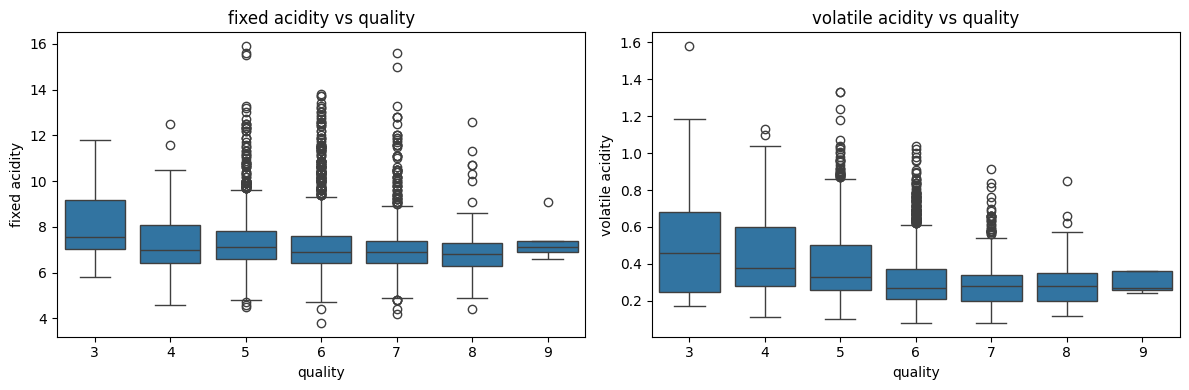

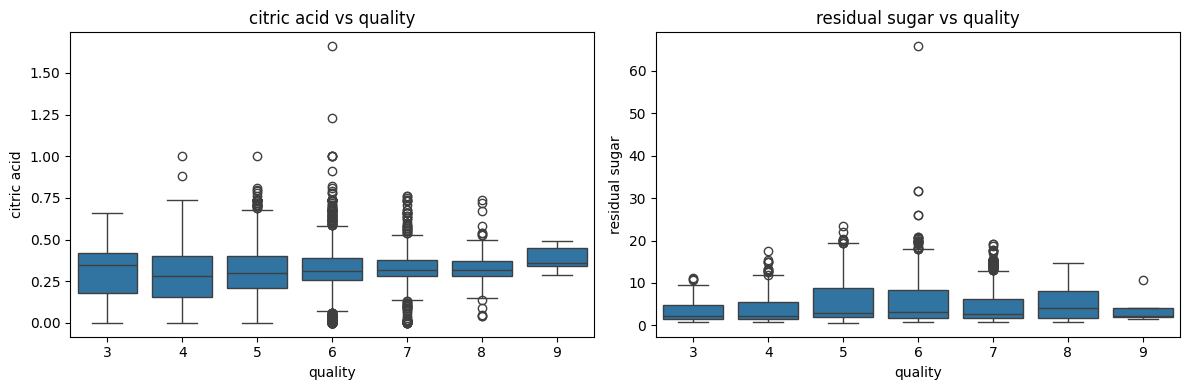

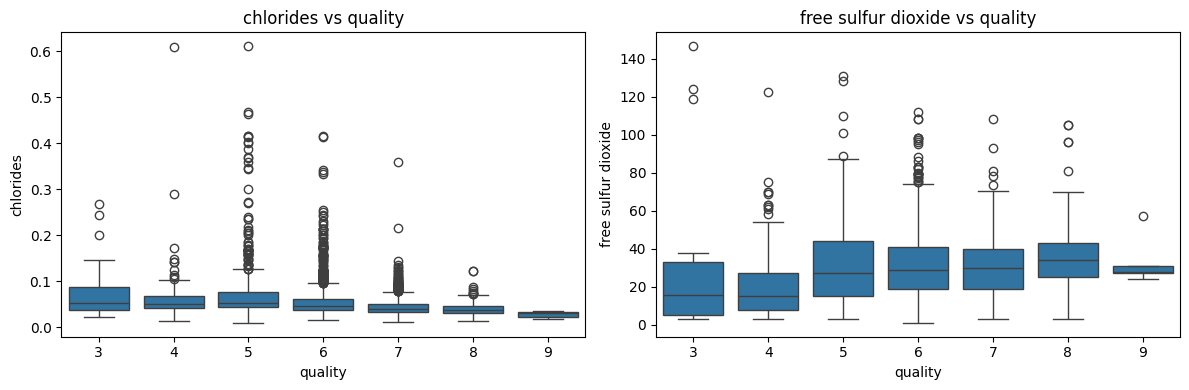

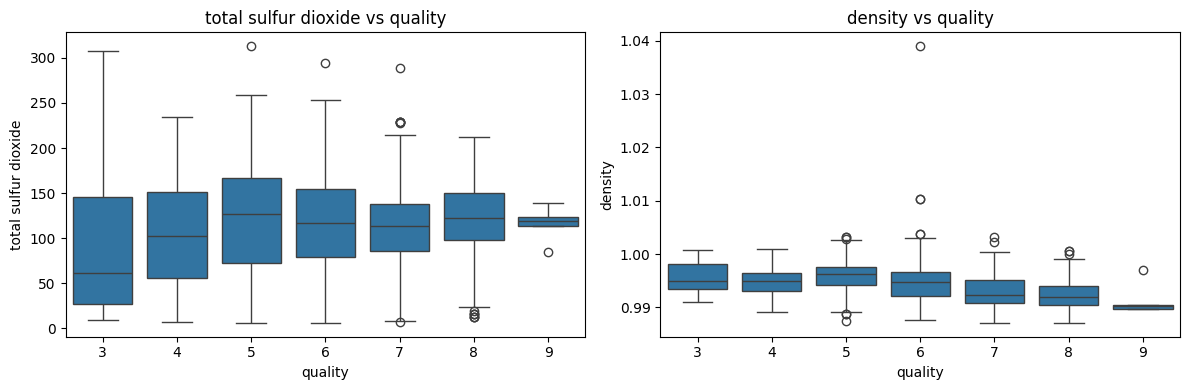

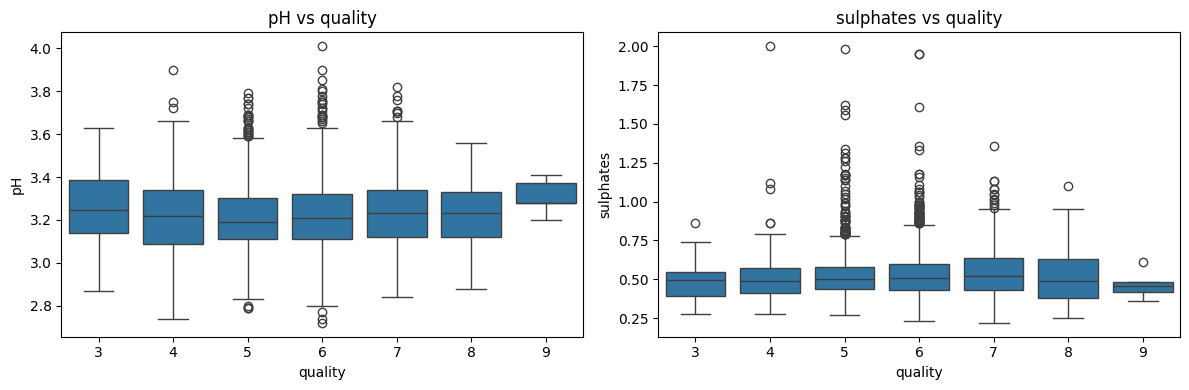

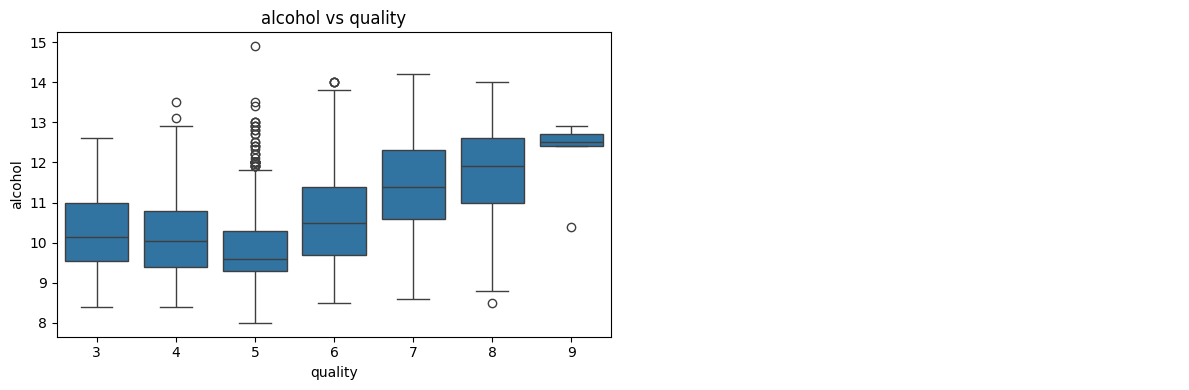

In [38]:
def boxplot_features_pairwise(df, features, target='quality'):
    # scorre le feature due a due
    for i in range(0, len(features), 2):

        fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

        # prima feature della coppia
        f1 = features[i]
        sns.boxplot(
            x=target,
            y=f1,
            data=df,
            ax=axes[0]
        )
        axes[0].set_title(f'{f1} vs {target}')

        # seconda feature (se esiste)
        if i + 1 < len(features):
            f2 = features[i + 1]
            sns.boxplot(
                x=target,
                y=f2,
                data=df,
                ax=axes[1]
            )
            axes[1].set_title(f'{f2} vs {target}')
        else:
            # se il numero di feature è dispari, nascondi il secondo subplot
            axes[1].axis('off')

        plt.tight_layout()
        plt.show()


boxplot_features_pairwise(df_train, features_names)

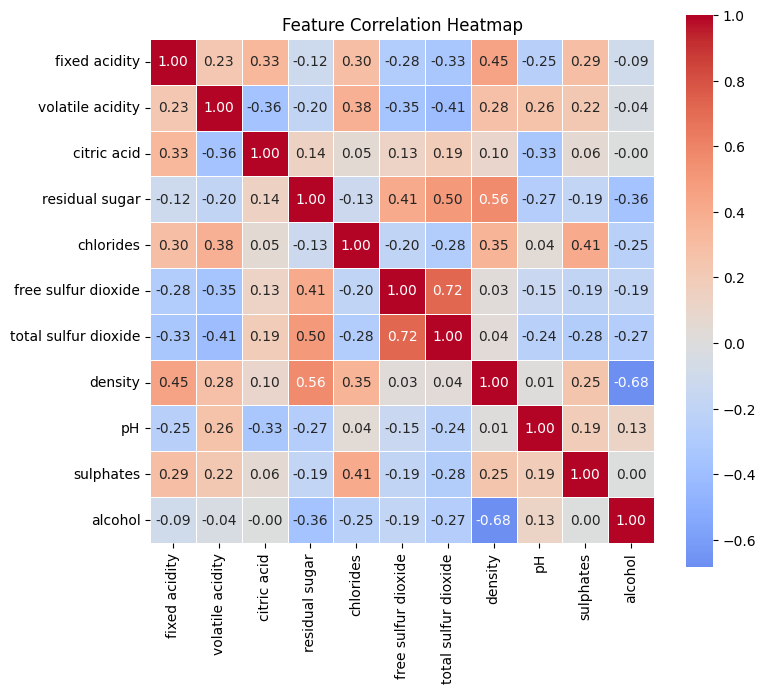

In [42]:
# matrice di correlazione
corr = df_train[features_names].corr()

plt.figure(figsize=(8, 8))
sns.heatmap(
    corr,
    annot=True,          # <-- mostra i valori
    fmt=".2f",           # <-- 2 cifre decimali (perfetto)
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

<h4>Feature Selection Outcome</h4>
<h5>Summary</h5>
<p>
Based on the combined evidence from boxplots and correlation analysis, the following conclusions were drawn:
<ul>
<li>Alcohol and volatile acidity are the most informative features and were retained in all configurations.</li>
<li>Sulphates, citric acid, and chlorides were identified as secondary features that may enhance performance when used in combination.</li>
<li>Fixed acidity, pH, residual sugar, and redundant sulfur dioxide measures were considered candidates for removal, pending validation.</li>
</ul>
Final decisions were deferred to model validation, ensuring that feature selection choices are supported by empirical performance rather than exploratory analysis alone.
</p>

<h5>Proposed Final Feature Subsets</h5>

Below are three proposed feature subsets, ordered from minimal to richer, all suitable for SVM models and fully justifiable in the report.

⸻

<b>Subset 1 – Minimal / Strong Signal</b>

Goal: low variance, high interpretability, baseline model.
<code>
alcohol
volatile acidity
</code>

<b>Subset 2 – Balanced / Recommended</b>

Goal: best trade-off between expressiveness and simplicity.
<code>
alcohol
volatile acidity
sulphates
citric acid
</code>

<b>Subset 3 – Extended / Conservative</b>

Goal: retain more information while avoiding major redundancy.
<code>
alcohol
volatile acidity
sulphates
citric acid
chlorides
total sulfur dioxide
</code>